In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import zipfile
import os
from scipy import stats
from openpyxl import Workbook
from openpyxl.utils.dataframe import dataframe_to_rows

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
# Define folder paths
raw_folder = "../data/raw"

# Check what files are inside your raw folder
files = os.listdir(raw_folder)
for file in files:
    print(file)

Automation_of_occupations_consequences_for_the_USA-master.zip
oesm19all.zip
oesm20all.zip
oesm21all.zip
oesm22all.zip
oesm23all.zip
oesm24all.zip


In [6]:
automation_zip = os.path.join(raw_folder, "Automation_of_occupations_consequences_for_the_USA-master.zip")

with zipfile.ZipFile(automation_zip, 'r') as z:
    for file in z.namelist():
        print(file)

Automation_of_occupations_consequences_for_the_USA-master/
Automation_of_occupations_consequences_for_the_USA-master/.gitignore
Automation_of_occupations_consequences_for_the_USA-master/Automation_of_occupations_consequences_for_the_USA.ipynb
Automation_of_occupations_consequences_for_the_USA-master/README.md
Automation_of_occupations_consequences_for_the_USA-master/data/
Automation_of_occupations_consequences_for_the_USA-master/data/US_population_2.csv
Automation_of_occupations_consequences_for_the_USA-master/data/automation_data_by_state.csv
Automation_of_occupations_consequences_for_the_USA-master/data/occupation_salary.xlsx
Automation_of_occupations_consequences_for_the_USA-master/img/
Automation_of_occupations_consequences_for_the_USA-master/img/general_Lost jobs ratio per state when we lost jobs with automatisation probability equal to 0.7 (Threshold) or higher.png
Automation_of_occupations_consequences_for_the_USA-master/img/general_Occupation categories and probability of autom

In [7]:
source = "Automation_of_occupations_consequences_for_the_USA-master/data/automation_data_by_state.csv"

with zipfile.ZipFile(automation_zip, 'r') as z:
    with z.open(source) as f:
        automation_df = pd.read_csv(f, encoding='latin-1')

print("Shape:", automation_df.shape)
print("\nFirst 5 rows:")
automation_df.head()

Shape: (702, 54)

First 5 rows:


,SOC,Occupation,Probability,Alabama,Alaska,Arizona,Arkansas,California,Colorado,Connecticut,...,South Dakota,Tennessee,Texas,Utah,Vermont,Virginia,Washington,West Virginia,Wisconsin,Wyoming
0,11-1011,Chief Executives,0.015,1030,760,5750,2710,31150,880,1410,...,560,5460,5890,3650,280,6320,5910,980,3740,160
1,11-1021,General and Operations Managers,0.160,26930,6490,43300,20680,261780,41540,33280,...,3730,44400,168610,36200,2760,52380,43760,10200,32350,4840
2,11-2011,Advertising and Promotions Managers,0.039,50,40,470,110,3760,480,300,...,0,670,1210,380,40,240,640,40,200,0
3,11-2021,Marketing Managers,0.014,530,200,4790,1090,33390,3060,4970,...,60,3400,9570,2320,380,3840,5830,260,2980,30
4,11-2022,Sales Managers,0.013,2510,400,10650,2650,69180,4570,7040,...,300,8890,22310,3360,480,5360,7390,600,5730,180


In [8]:
automation_clean = automation_df[['SOC', 'Occupation', 'Probability']].copy()
automation_clean.columns = ['soc_code', 'occupation', 'automation_probability']

print("Shape:", automation_clean.shape)
print("\nMissing values:")
print(automation_clean.isnull().sum())
print("\nFirst 5 rows:")
print(automation_clean.head())

Shape: (702, 3)

Missing values:
soc_code                  0
occupation                0
automation_probability    0
dtype: int64

First 5 rows:
  soc_code                           occupation  automation_probability
0  11-1011                     Chief Executives                   0.015
1  11-1021      General and Operations Managers                   0.160
2  11-2011  Advertising and Promotions Managers                   0.039
3  11-2021                   Marketing Managers                   0.014
4  11-2022                       Sales Managers                   0.013


In [9]:
bls_files = {
    2019: "oesm19all.zip",
    2020: "oesm20all.zip",
    2021: "oesm21all.zip",
    2022: "oesm22all.zip",
    2023: "oesm23all.zip",
    2024: "oesm24all.zip",
}

all_years = []

for year, filename in bls_files.items():
    zip_path = os.path.join(raw_folder, filename)
    with zipfile.ZipFile(zip_path, 'r') as z:
        inner_file = f"oesm{str(year)[2:]}all/all_data_M_{year}.xlsx"
        with z.open(inner_file) as f:
            df = pd.read_excel(f, dtype=str)
            df.columns = df.columns.str.lower()
            df['year'] = year
            all_years.append(df)
    print(f"{year} loaded — shape: {df.shape}")

bls_df = pd.concat(all_years, ignore_index=True)
bls_df = bls_df.loc[:, ~bls_df.columns.duplicated()]

print(f"\nTotal combined shape: {bls_df.shape}")

2019 loaded — shape: (395647, 31)
2020 loaded — shape: (390705, 32)
2021 loaded — shape: (406359, 33)
2022 loaded — shape: (409859, 33)
2023 loaded — shape: (413327, 33)
2024 loaded — shape: (414437, 33)

Total combined shape: (2430334, 34)


In [10]:
bls_clean = bls_df[[
    'year', 'occ_code', 'occ_title', 'o_group', 'tot_emp', 'area_type'
]].copy()

print("Shape:", bls_clean.shape)
print("\nUnique values in o_group:", bls_clean['o_group'].unique())
print("Unique values in area_type:", bls_clean['area_type'].unique())

Shape: (2430334, 6)

Unique values in o_group: ['major' 'detailed' 'broad' 'minor' 'total']
Unique values in area_type: ['1' '2' '3' '6' '4']


In [11]:
bls_filtered = bls_clean[
    (bls_clean['area_type'] == '1') &
    (bls_clean['o_group'] == 'detailed')
].copy()

bls_filtered['tot_emp'] = pd.to_numeric(bls_filtered['tot_emp'], errors='coerce')

print("Shape after filtering:", bls_filtered.shape)
print("\nUnique years:", sorted(bls_filtered['year'].unique()))
print("\nSample rows:")
print(bls_filtered.head())

Shape after filtering: (493239, 6)

Unique years: [2019, 2020, 2021, 2022, 2023, 2024]

Sample rows:
    year occ_code                            occ_title   o_group    tot_emp  \
22  2019  11-1011                     Chief Executives  detailed   205890.0   
23  2019  11-1021      General and Operations Managers  detailed  2400280.0   
24  2019  11-1031                          Legislators  detailed    52280.0   
25  2019  11-2011  Advertising and Promotions Managers  detailed    25100.0   
26  2019  11-2021                   Marketing Managers  detailed   263680.0   

   area_type  
22         1  
23         1  
24         1  
25         1  
26         1  


In [12]:
merged_df = bls_filtered.merge(
    automation_clean,
    left_on='occ_code',
    right_on='soc_code',
    how='left'
)

merged_df = merged_df.dropna(subset=['automation_probability'])

print("Shape after merge:", merged_df.shape)
print("\nUnique years:", sorted(merged_df['year'].unique()))
print("\nSample rows:")
print(merged_df[['year', 'occ_code', 'occ_title', 'tot_emp', 'automation_probability']].head())

Shape after merge: (367057, 9)

Unique years: [2019, 2020, 2021, 2022, 2023, 2024]

Sample rows:
   year occ_code                            occ_title    tot_emp  \
0  2019  11-1011                     Chief Executives   205890.0   
1  2019  11-1021      General and Operations Managers  2400280.0   
3  2019  11-2011  Advertising and Promotions Managers    25100.0   
4  2019  11-2021                   Marketing Managers   263680.0   
5  2019  11-2022                       Sales Managers   402600.0   

   automation_probability  
0                   0.015  
1                   0.160  
3                   0.039  
4                   0.014  
5                   0.013  


In [13]:
merged_df['disruption_index'] = merged_df['automation_probability'] * 100

yearly_summary = merged_df.groupby('year').agg(
    total_employment=('tot_emp', 'sum'),
    avg_disruption=('disruption_index', 'mean'),
    occupation_count=('occ_code', 'nunique')
).reset_index()

print("Yearly summary:")
print(yearly_summary)

Yearly summary:
   year  total_employment  avg_disruption  occupation_count
0  2019       601156180.0       53.185890               601
1  2020       564524000.0       53.181172               601
2  2021       581226190.0       52.460966               605
3  2022       608514010.0       52.354516               604
4  2023       620650440.0       52.169973               605
5  2024       629687600.0       52.083157               605


In [14]:
occupation_risk = merged_df[['occ_code', 'occ_title', 'automation_probability', 'disruption_index']]\
    .drop_duplicates(subset='occ_code')\
    .sort_values('disruption_index', ascending=False)

print("TOP 10 MOST AT-RISK OCCUPATIONS:")
print(occupation_risk.head(10)[['occ_title', 'disruption_index']].to_string(index=False))

print("\nTOP 10 SAFEST OCCUPATIONS:")
print(occupation_risk.tail(10)[['occ_title', 'disruption_index']].to_string(index=False))

TOP 10 MOST AT-RISK OCCUPATIONS:
                                                    occ_title  disruption_index
                                          Library Technicians              99.0
                                                Tax Preparers              99.0
                                            Data Entry Keyers              99.0
Photographic Process Workers and Processing Machine Operators              99.0
                  Title Examiners, Abstractors, and Searchers              99.0
                                                 Sewers, Hand              99.0
                                    Watch and Clock Repairers              99.0
                                          New Accounts Clerks              99.0
                                                Telemarketers              99.0
                                       Insurance Underwriters              99.0

TOP 10 SAFEST OCCUPATIONS:
                                                     occ_ti

In [15]:
agg_df = merged_df.groupby(
    ['year', 'occ_code', 'occ_title', 'disruption_index'], as_index=False
)['tot_emp'].sum()

emp_2019 = agg_df[agg_df['year'] == 2019][['occ_code', 'tot_emp']].rename(columns={'tot_emp': 'emp_2019'})
emp_2024 = agg_df[agg_df['year'] == 2024][['occ_code', 'tot_emp']].rename(columns={'tot_emp': 'emp_2024'})

emp_change = emp_2019.merge(emp_2024, on='occ_code')
emp_change['pct_change'] = ((emp_change['emp_2024'] - emp_change['emp_2019']) / emp_change['emp_2019']) * 100
emp_change = emp_change.merge(occupation_risk[['occ_code', 'disruption_index']], on='occ_code')

print("Shape:", emp_change.shape)
print("\nSample rows:")
print(emp_change.head())

Shape: (600, 5)

Sample rows:
  occ_code    emp_2019    emp_2024  pct_change  disruption_index
0  11-1011   1099540.0   1165340.0    5.984321               1.5
1  11-1021  12629030.0  18939610.0   49.968842              16.0
2  11-2011    126120.0    104200.0  -17.380273               3.9
3  11-2021   1358400.0   1993960.0   46.787397               1.4
4  11-2022   2051210.0   3084110.0   50.355644               1.3


Slope:   -0.1841
R²:      0.0886
P-value: 0.000000 (significant)


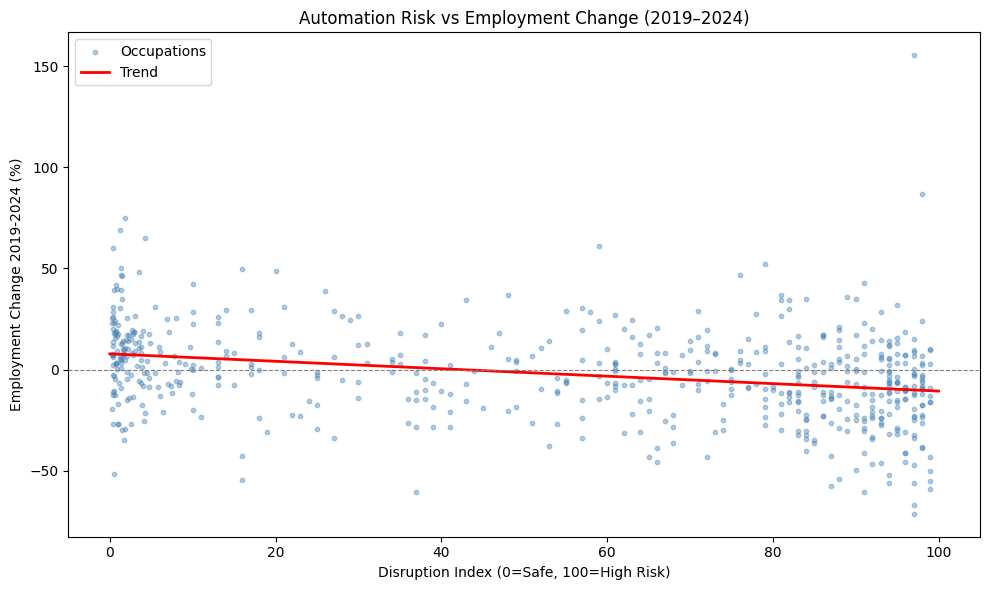

Chart saved!


In [16]:
slope, intercept, r_value, p_val, std_err = stats.linregress(
    emp_change['disruption_index'], emp_change['pct_change']
)

print(f"Slope:   {slope:.4f}")
print(f"R²:      {r_value**2:.4f}")
print(f"P-value: {p_val:.6f} ({'significant' if p_val < 0.05 else 'NOT significant'})")

x_line = np.linspace(0, 100, 100)

plt.figure(figsize=(10, 6))
plt.scatter(emp_change['disruption_index'], emp_change['pct_change'],
            alpha=0.4, s=10, color='steelblue', label='Occupations')
plt.plot(x_line, intercept + slope * x_line, color='red', linewidth=2, label='Trend')
plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.xlabel('Disruption Index (0=Safe, 100=High Risk)')
plt.ylabel('Employment Change 2019-2024 (%)')
plt.title('Automation Risk vs Employment Change (2019–2024)')
plt.legend()
plt.tight_layout()
plt.savefig('../charts/disruption_trend.png', dpi=150)
plt.show()
print("Chart saved!")

Full period (2019–2024): slope=-0.1841  R²=0.089  p=0.000000
Post-COVID (2021–2024):  slope=-0.1416  R²=0.052  p=0.000000


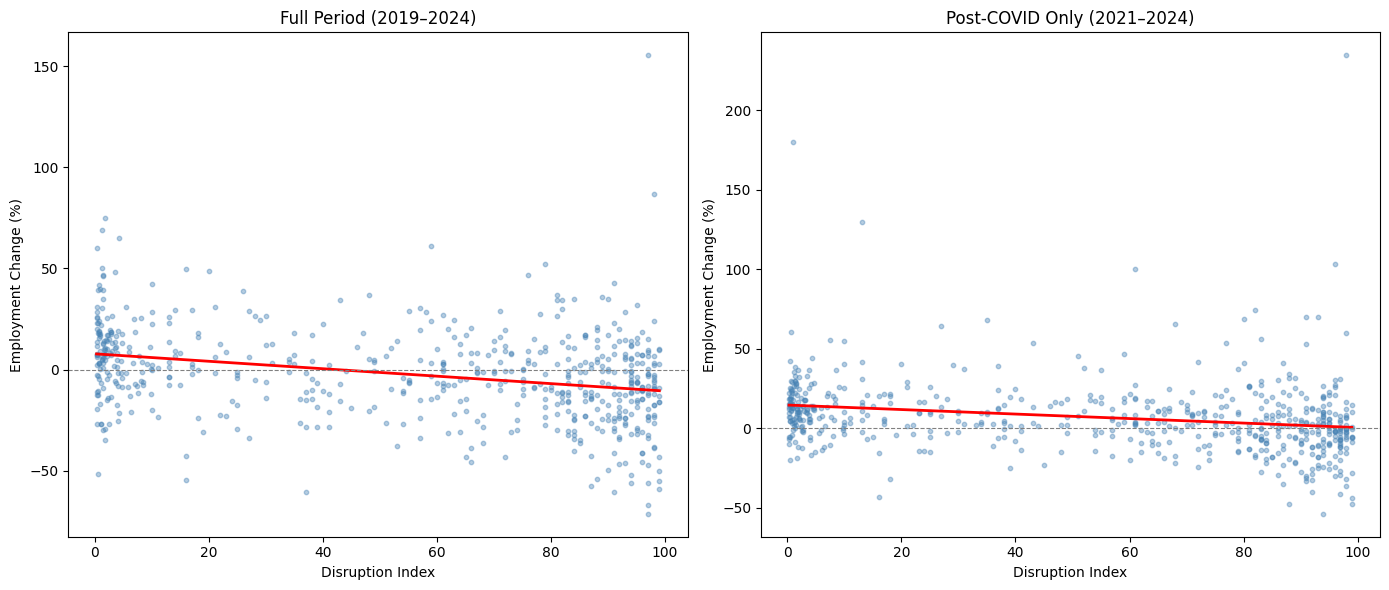

Chart saved!


In [17]:
emp_2021 = agg_df[agg_df['year'] == 2021][['occ_code', 'tot_emp']].rename(
    columns={'tot_emp': 'emp_2021'})

post_covid = emp_2021.merge(emp_2024, on='occ_code')
post_covid['pct_change'] = ((post_covid['emp_2024'] - post_covid['emp_2021'])
                             / post_covid['emp_2021']) * 100
post_covid = post_covid.merge(
    occupation_risk[['occ_code', 'disruption_index']], on='occ_code')

slope_pc, intercept_pc, r_pc, p_pc, _ = stats.linregress(
    post_covid['disruption_index'], post_covid['pct_change'])

print(f"Full period (2019–2024): slope={slope:.4f}  R²={r_value**2:.3f}  p={p_val:.6f}")
print(f"Post-COVID (2021–2024):  slope={slope_pc:.4f}  R²={r_pc**2:.3f}  p={p_pc:.6f}")

x_sorted      = emp_change['disruption_index'].sort_values()
x_sorted_pc   = post_covid['disruption_index'].sort_values()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.scatter(emp_change['disruption_index'], emp_change['pct_change'],
            alpha=0.4, s=10, color='steelblue')
ax1.plot(x_sorted, intercept + slope * x_sorted, color='red', linewidth=2)
ax1.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax1.set_title('Full Period (2019–2024)')
ax1.set_xlabel('Disruption Index')
ax1.set_ylabel('Employment Change (%)')

ax2.scatter(post_covid['disruption_index'], post_covid['pct_change'],
            alpha=0.4, s=10, color='steelblue')
ax2.plot(x_sorted_pc, intercept_pc + slope_pc * x_sorted_pc, color='red', linewidth=2)
ax2.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax2.set_title('Post-COVID Only (2021–2024)')
ax2.set_xlabel('Disruption Index')
ax2.set_ylabel('Employment Change (%)')

plt.tight_layout()
plt.savefig('../charts/covid_sensitivity.png', dpi=150)
plt.show()
print("Chart saved!")

In [18]:
wage_df = bls_df[
    (bls_df['area_type'] == '1') &
    (bls_df['o_group'] == 'detailed') &
    (bls_df['year'] == 2024)
][['occ_code', 'a_median', 'tot_emp']].copy()

wage_df['a_median'] = pd.to_numeric(wage_df['a_median'], errors='coerce')
wage_df['tot_emp']  = pd.to_numeric(wage_df['tot_emp'],  errors='coerce')

wage_df = wage_df.sort_values('tot_emp', ascending=False)
wage_df = wage_df.drop_duplicates(subset='occ_code', keep='first')

print("Unique occupations in wage_df:", wage_df.shape[0])
print("\nSample rows:")
print(wage_df.head())

Unique occupations in wage_df: 831

Sample rows:
        occ_code  a_median    tot_emp
2016510  31-1120   34900.0  3988140.0
2016701  41-2031   34580.0  3800250.0
2016596  35-3023   30480.0  3780930.0
2015903  11-1021  102950.0  3584420.0
2016437  29-1141   93600.0  3282010.0


In [19]:
wage_analysis = occupation_risk.merge(wage_df, on='occ_code', how='inner')
wage_analysis = wage_analysis.dropna(subset=['a_median', 'tot_emp'])

print("Shape:", wage_analysis.shape)
print("\nSample:")
print(wage_analysis[['occ_title', 'automation_probability', 'a_median', 'tot_emp']].head())

Shape: (599, 6)

Sample:
                                           occ_title  automation_probability  \
0                                Library Technicians                    0.99   
1                                      Tax Preparers                    0.99   
2                                  Data Entry Keyers                    0.99   
3  Photographic Process Workers and Processing Ma...                    0.99   
4        Title Examiners, Abstractors, and Searchers                    0.99   

   a_median   tot_emp  
0   39970.0   73770.0  
1   50560.0   73570.0  
2   39850.0  135280.0  
3   40100.0    5550.0  
4   54980.0   48170.0  


In [20]:
def risk_label(prob):
    if prob >= 0.70:
        return 'High Risk (>=70%)'
    elif prob >= 0.30:
        return 'Medium Risk (30-69%)'
    else:
        return 'Low Risk (<30%)'

wage_analysis['risk_category'] = wage_analysis['automation_probability'].apply(risk_label)

print("Occupations per risk category:")
print(wage_analysis['risk_category'].value_counts())

print("\nAverage median wage by risk category:")
print(wage_analysis.groupby('risk_category')['a_median'].mean().sort_values())

Occupations per risk category:
risk_category
High Risk (>=70%)       283
Low Risk (<30%)         198
Medium Risk (30-69%)    118
Name: count, dtype: int64

Average median wage by risk category:
risk_category
High Risk (>=70%)       51422.614841
Medium Risk (30-69%)    61511.694915
Low Risk (<30%)         86047.525253
Name: a_median, dtype: float64


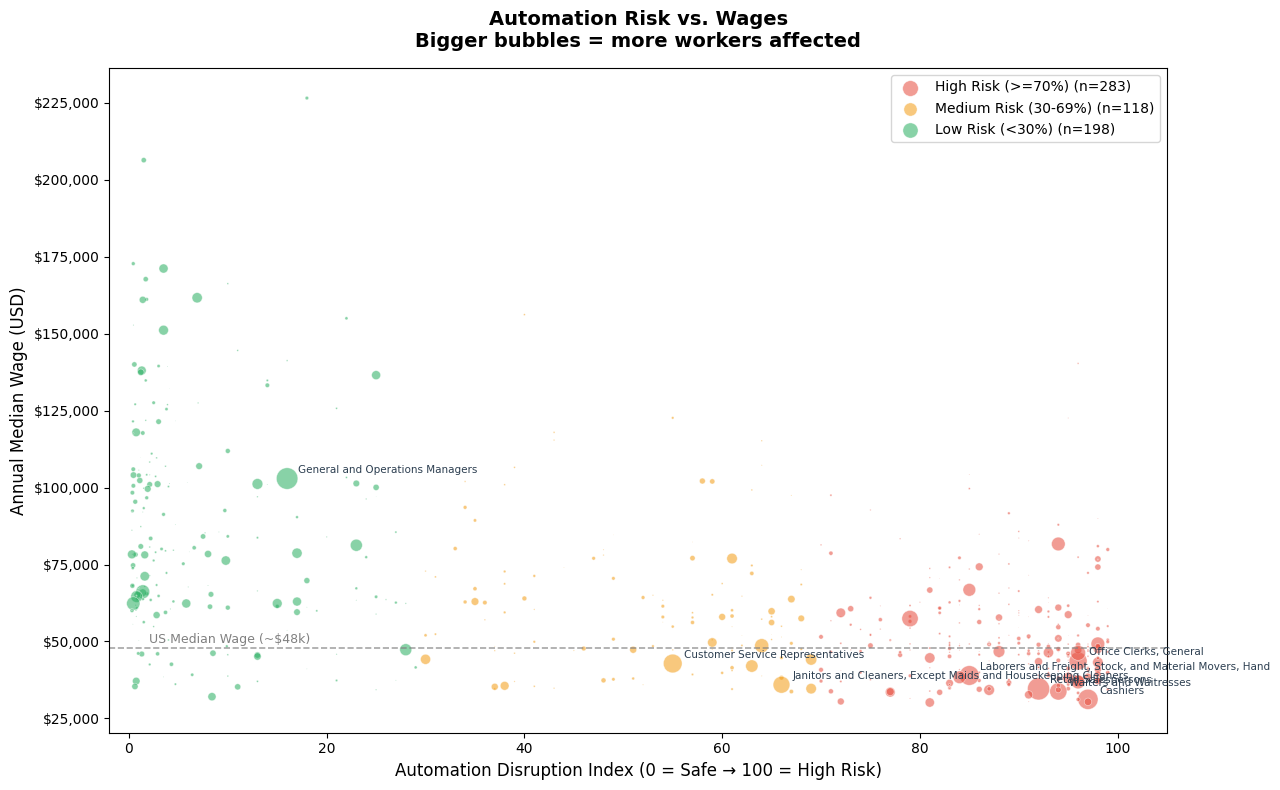

Chart saved!


In [21]:
colors = {
    'High Risk (>=70%)':    '#e74c3c',
    'Medium Risk (30-69%)': '#f39c12',
    'Low Risk (<30%)':      '#27ae60'
}

fig, ax = plt.subplots(figsize=(13, 8))

for category, color in colors.items():
    subset = wage_analysis[wage_analysis['risk_category'] == category]
    ax.scatter(
        subset['disruption_index'],
        subset['a_median'],
        s         = subset['tot_emp'] / 15000,
        c         = color,
        alpha     = 0.55,
        edgecolors= 'white',
        linewidths= 0.5,
        label     = f"{category} (n={len(subset)})"
    )

top_bubbles = wage_analysis.nlargest(8, 'tot_emp')
for _, row in top_bubbles.iterrows():
    ax.annotate(
        row['occ_title'],
        xy        = (row['disruption_index'], row['a_median']),
        xytext    = (8, 4),
        textcoords= 'offset points',
        fontsize  = 7.5,
        color     = '#2c3e50'
    )

ax.axhline(y=48000, color='gray', linewidth=1.2, linestyle='--', alpha=0.7)
ax.text(2, 49500, 'US Median Wage (~$48k)', fontsize=9, color='gray')

def dollar_format(value, pos):
    return f'${value:,.0f}'

ax.set_xlabel('Automation Disruption Index (0 = Safe → 100 = High Risk)', fontsize=12)
ax.set_ylabel('Annual Median Wage (USD)', fontsize=12)
ax.set_title('Automation Risk vs. Wages\nBigger bubbles = more workers affected',
             fontsize=14, fontweight='bold', pad=15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))
ax.legend(fontsize=10, loc='upper right')
ax.set_xlim(-2, 105)
plt.tight_layout()
plt.savefig('../charts/wage_vs_automation_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [22]:
summary = wage_analysis.groupby('risk_category').agg(
    avg_wage         = ('a_median', 'mean'),
    median_wage      = ('a_median', 'median'),
    total_workers    = ('tot_emp', 'sum'),
    num_occupations  = ('occ_code', 'count')
).reindex(['Low Risk (<30%)', 'Medium Risk (30-69%)', 'High Risk (>=70%)'])

print("=" * 60)
print("KEY FINDING — Wage vs Automation Risk Summary")
print("=" * 60)
for category, row in summary.iterrows():
    print(f"\n{category}")
    print(f"  Average wage     : ${row['avg_wage']:>10,.0f}")
    print(f"  Median wage      : ${row['median_wage']:>10,.0f}")
    print(f"  Total workers    : {row['total_workers']/1e6:>8.1f}M")
    print(f"  Num occupations  : {row['num_occupations']:>8}")

KEY FINDING — Wage vs Automation Risk Summary

Low Risk (<30%)
  Average wage     : $    86,048
  Median wage      : $    78,845
  Total workers    :     37.6M
  Num occupations  :    198.0

Medium Risk (30-69%)
  Average wage     : $    61,512
  Median wage      : $    57,150
  Total workers    :     21.1M
  Num occupations  :    118.0

High Risk (>=70%)
  Average wage     : $    51,423
  Median wage      : $    48,350
  Total workers    :     55.6M
  Num occupations  :    283.0


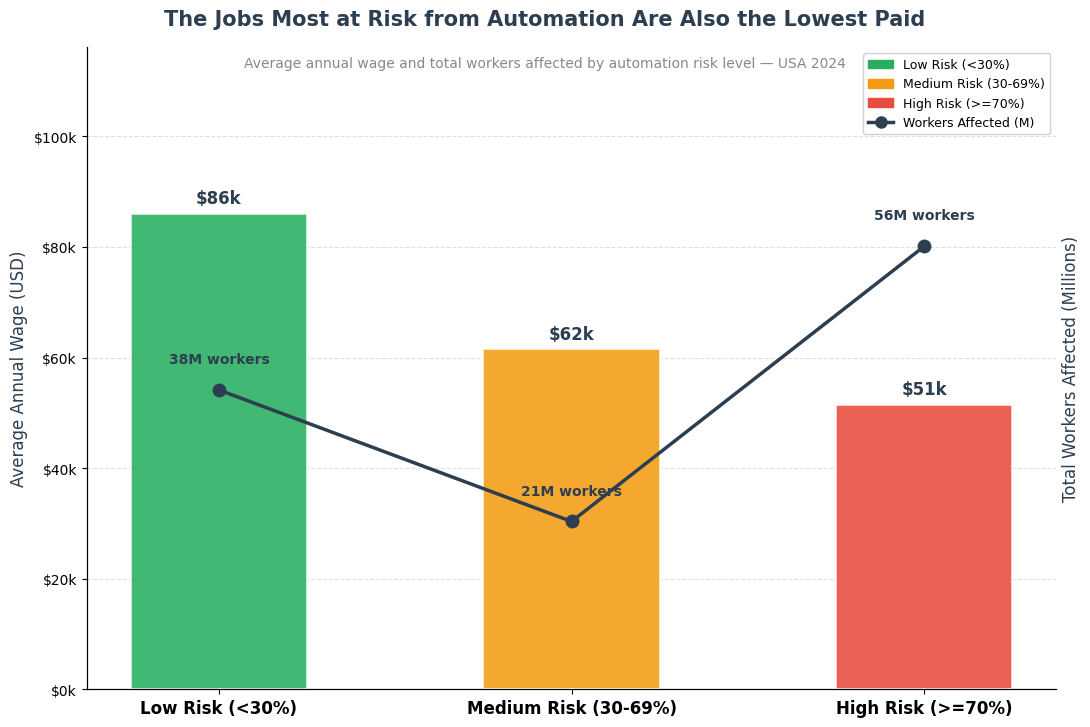

Chart saved!


In [23]:
categories = summary.index.tolist()
wages      = (summary['avg_wage'] / 1000).tolist()
workers    = (summary['total_workers'] / 1_000_000).tolist()
bar_colors = ['#27ae60', '#f39c12', '#e74c3c']

fig, ax1 = plt.subplots(figsize=(11, 7))
ax2 = ax1.twinx()

x         = np.arange(len(categories))
bar_width = 0.5

bars = ax1.bar(x, wages, width=bar_width, color=bar_colors,
               alpha=0.88, zorder=3, edgecolor='white', linewidth=1.2)

ax2.plot(x, workers, color='#2c3e50', linewidth=2.5,
         marker='o', markersize=9, zorder=4, label='Workers Affected (Millions)')

for bar, wage in zip(bars, wages):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 1.2,
             f'${wage:,.0f}k',
             ha='center', va='bottom',
             fontsize=12, fontweight='bold', color='#2c3e50')

for i, val in enumerate(workers):
    ax2.text(i, val + 3, f'{val:.0f}M workers',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold', color='#2c3e50')

def dollar_format_k(value, pos):
    return f'${value:,.0f}k'

ax1.set_ylabel('Average Annual Wage (USD)', fontsize=12, color='#2c3e50')
ax2.set_ylabel('Total Workers Affected (Millions)', fontsize=12, color='#2c3e50')
ax1.set_xticks(x)
ax1.set_xticklabels(categories, fontsize=12, fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format_k))
ax1.set_ylim(0, max(wages) * 1.35)
ax2.set_ylim(0, max(workers) * 1.45)
ax2.tick_params(right=False, labelright=False)
ax1.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

bar_legend = [
    mpatches.Patch(color='#27ae60', label='Low Risk (<30%)'),
    mpatches.Patch(color='#f39c12', label='Medium Risk (30-69%)'),
    mpatches.Patch(color='#e74c3c', label='High Risk (>=70%)'),
]
line_legend, = ax2.plot([], [], color='#2c3e50', linewidth=2.5,
                        marker='o', markersize=8, label='Workers Affected (M)')
ax1.legend(handles=bar_legend + [line_legend], loc='upper right',
           fontsize=9, framealpha=0.9)

fig.text(0.5, 1.01,
         'The Jobs Most at Risk from Automation Are Also the Lowest Paid',
         ha='center', fontsize=15, fontweight='bold', color='#2c3e50')
fig.text(0.5, 0.95,
         'Average annual wage and total workers affected by automation risk level — USA 2024',
         ha='center', fontsize=10, color='#7f8c8d')

plt.tight_layout()
plt.savefig('../charts/wage_vs_risk_clean.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [24]:
os.makedirs('../output', exist_ok=True)

wb = Workbook()

# Sheet 1 — Yearly Summary
ws1 = wb.active
ws1.title = "Yearly Summary"
for r in dataframe_to_rows(yearly_summary, index=False, header=True):
    ws1.append(r)

# Sheet 2 — Top 20 At Risk
ws2 = wb.create_sheet("Most At Risk")
top20 = occupation_risk.head(20)[['occ_title', 'disruption_index']]
for r in dataframe_to_rows(top20, index=False, header=True):
    ws2.append(r)

# Sheet 3 — Employment Change
ws3 = wb.create_sheet("Employment Change")
output = emp_change.merge(
    occupation_risk[['occ_code', 'occ_title']], on='occ_code'
)[['occ_title', 'emp_2019', 'emp_2024', 'pct_change', 'disruption_index']]
output = output.sort_values('pct_change')
for r in dataframe_to_rows(output, index=False, header=True):
    ws3.append(r)

# Sheet 4 — Wage vs Risk Summary
ws4 = wb.create_sheet("Wage vs Risk")
for r in dataframe_to_rows(summary.reset_index(), index=False, header=True):
    ws4.append(r)

wb.save('../output/labor_disruption_report.xlsx')
print("Report saved!")

Report saved!
